# Uber Fare Prediction Model
**Business objective:** estimate expected fare before trip completion using historical ride information.

> Source note: the supplied 50K dataset does not contain `passenger_count`; this project does not fabricate it.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from pathlib import Path

## 2. Load Dataset

In [2]:
DATA_PATH = Path('../dataset/uber_trips_dataset_50k.csv')
df = pd.read_csv(DATA_PATH)
print(df.shape)
display(df.head())

(50000, 14)


,trip_id,driver_id,rider_id,city,pickup_lat,pickup_lng,drop_lat,drop_lng,distance_km,fare_amount,status,payment_method,pickup_time,drop_time
0,1,8270,10683,San Francisco,37.170931,-77.586479,37.173652,-77.619934,2.97,10.71,Completed,Wallet,2023-01-01 00:00:00,2023-01-01 00:08:54.600000000
1,2,1860,44743,Boston,38.898127,-108.582977,38.937464,-108.558727,8.43,22.41,Completed,UPI,2023-01-01 00:01:00,2023-01-01 00:26:17.400000000
2,3,6390,75839,San Francisco,38.814571,-89.942603,38.821702,-89.896435,5.46,12.91,Completed,Cash,2023-01-01 00:02:00,2023-01-01 00:18:22.800000000
3,4,6191,22189,New York,37.295906,-75.328844,37.301375,-75.317488,6.61,15.70,Completed,Wallet,2023-01-01 00:03:00,2023-01-01 00:22:49.800000000
4,5,6734,61104,Seattle,38.972395,-121.482913,38.992088,-121.467904,10.50,19.15,Completed,Wallet,2023-01-01 00:04:00,2023-01-01 00:35:30.000000000


## 3. Data Understanding

In [3]:
print(df.info())
print('Missing values:')
display(df.isna().sum().to_frame('missing'))
print('Duplicates:', df.duplicated().sum())
display(df.describe(include='all').T)

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   trip_id         50000 non-null  int64  
 1   driver_id       50000 non-null  int64  
 2   rider_id        50000 non-null  int64  
 3   city            50000 non-null  str    
 4   pickup_lat      50000 non-null  float64
 5   pickup_lng      50000 non-null  float64
 6   drop_lat        50000 non-null  float64
 7   drop_lng        50000 non-null  float64
 8   distance_km     50000 non-null  float64
 9   fare_amount     50000 non-null  float64
 10  status          50000 non-null  str    
 11  payment_method  50000 non-null  str    
 12  pickup_time     50000 non-null  str    
 13  drop_time       50000 non-null  str    
dtypes: float64(6), int64(3), str(5)
memory usage: 8.7 MB
None
Missing values:


,missing
trip_id,0
driver_id,0
rider_id,0
city,0
pickup_lat,0
pickup_lng,0
drop_lat,0
drop_lng,0
distance_km,0
fare_amount,0


Duplicates: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
trip_id,50000.0,NaN,NaN,NaN,25000.5,14433.901067,1.0,12500.75,25000.5,37500.25,50000.0
driver_id,50000.0,NaN,NaN,NaN,5493.95454,2601.410798,1000.0,3232.75,5497.0,7746.0,9998.0
rider_id,50000.0,NaN,NaN,NaN,55040.99458,25915.467105,10001.0,32539.0,55164.0,77293.5,99998.0
city,50000,6,Boston,8454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup_lat,50000.0,NaN,NaN,NaN,38.998664,1.155241,37.000009,37.994428,38.992589,39.999602,40.999937
pickup_lng,50000.0,NaN,NaN,NaN,-97.485552,14.173744,-121.999465,-109.818282,-97.463042,-85.190954,-73.001961
drop_lat,50000.0,NaN,NaN,NaN,38.998768,1.155696,36.953365,37.998237,38.99419,39.998849,41.047536
drop_lng,50000.0,NaN,NaN,NaN,-97.485677,14.173735,-122.047124,-109.81726,-97.464646,-85.199652,-72.963476
distance_km,50000.0,NaN,NaN,NaN,7.00807,2.946744,0.0,4.98,6.98,9.0,19.41
fare_amount,50000.0,NaN,NaN,NaN,15.976205,6.274406,1.08,11.51,15.43,19.91,50.67


## 4. Data Cleaning and Feature Engineering

In [4]:
for c in ['pickup_time','drop_time']:
    df[c] = pd.to_datetime(df[c], errors='coerce')

df = df.drop_duplicates().dropna(subset=['fare_amount','distance_km','pickup_lat','pickup_lng','drop_lat','drop_lng','pickup_time','drop_time']).copy()
df = df[(df['fare_amount'] > 0) & (df['distance_km'] > 0)]
df = df[df['pickup_lat'].between(-90,90) & df['drop_lat'].between(-90,90) & df['pickup_lng'].between(-180,180) & df['drop_lng'].between(-180,180)]

df['pickup_year']=df.pickup_time.dt.year
df['pickup_month']=df.pickup_time.dt.month
df['pickup_day']=df.pickup_time.dt.day
df['pickup_hour']=df.pickup_time.dt.hour
df['day_of_week']=df.pickup_time.dt.dayofweek
df['day_name']=df.pickup_time.dt.day_name()
df['is_weekend']=df.day_of_week.isin([5,6]).astype(int)
df['is_rush_hour']=df.pickup_hour.isin([7,8,9,16,17,18,19]).astype(int)
df['trip_duration_min']=(df.drop_time-df.pickup_time).dt.total_seconds()/60
df=df[df.trip_duration_min>0].copy()
df['fare_per_km']=np.where(df.distance_km>0,df.fare_amount/df.distance_km,np.nan)
print(df.shape)

(49997, 24)


## 5. Exploratory Data Analysis

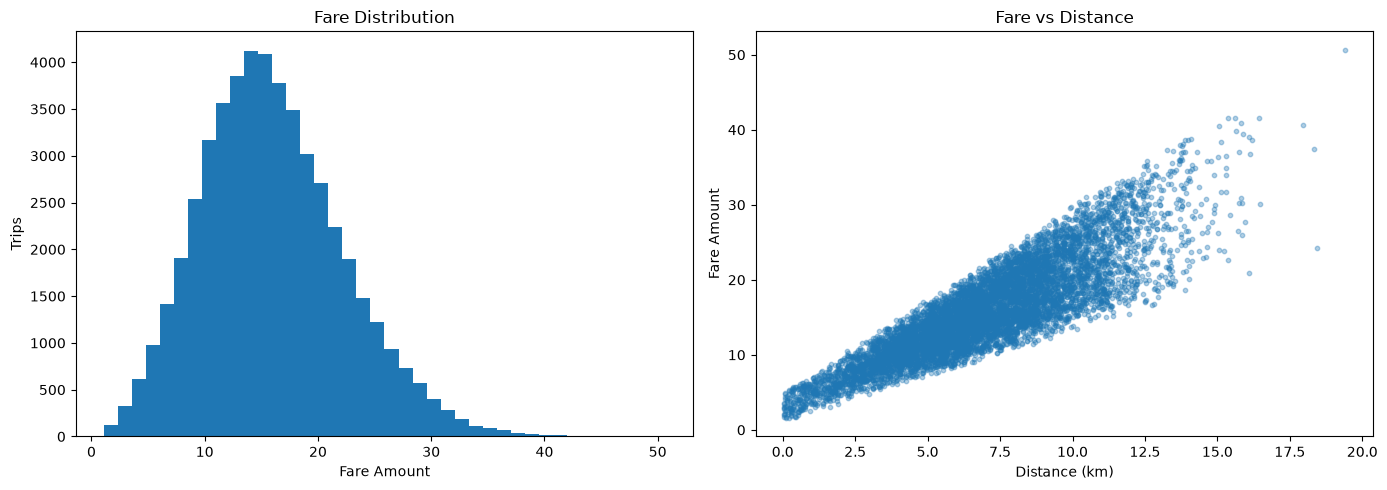

Fare-distance correlation: 0.8705972565295098


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['fare_amount'], bins=40)
axes[0].set_title('Fare Distribution')
axes[0].set_xlabel('Fare Amount')
axes[0].set_ylabel('Trips')

sample_df = df.sample(min(8000, len(df)), random_state=42)
axes[1].scatter(sample_df['distance_km'], sample_df['fare_amount'], alpha=0.35, s=10)
axes[1].set_title('Fare vs Distance')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Fare Amount')

plt.tight_layout()
plt.show()
print('Fare-distance correlation:', df[['fare_amount', 'distance_km']].corr().iloc[0, 1])

In [6]:
display(df.groupby('city').agg(trips=('trip_id','count'),avg_fare=('fare_amount','mean'),avg_distance=('distance_km','mean')).sort_values('avg_fare',ascending=False))
display(df.groupby('pickup_hour').fare_amount.mean().to_frame('avg_fare'))
display(pd.crosstab(df['city'],df['status'],normalize='index').round(3))

,trips,avg_fare,avg_distance
city,,,
Seattle,8236,16.062084,7.068548
Boston,8454,16.052095,7.023998
New York,8247,16.048470,7.014101
San Francisco,8401,16.023240,7.030908
Chicago,8344,15.902384,6.962480
Los Angeles,8315,15.773431,6.951195


,avg_fare
pickup_hour,
0,15.773952
1,15.917548
2,15.781581
3,16.156305
4,15.962595
5,15.965238
6,16.158371
7,15.868986
8,16.128251


status,Cancelled,Completed,No-Show
city,,,
Boston,0.103,0.850,0.047
Chicago,0.101,0.850,0.050
Los Angeles,0.102,0.846,0.052
New York,0.098,0.853,0.049
San Francisco,0.097,0.852,0.051
Seattle,0.098,0.855,0.048


## 6. Modeling Dataset
Use only completed trips. Do not use IDs, trip status, actual drop time or actual trip duration as fare-prediction features.

In [7]:
model_df=df[df.status=='Completed'].copy()
features=['city','payment_method','pickup_lat','pickup_lng','drop_lat','drop_lng','distance_km','pickup_year','pickup_month','pickup_day','pickup_hour','day_of_week','is_weekend','is_rush_hour']
X=model_df[features]; y=model_df['fare_amount']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)
print(X_train.shape,X_test.shape)

(34030, 14) (8508, 14)


## 7. Preprocessing and Model Training

In [8]:
cat=['city','payment_method']; num=[c for c in features if c not in cat]
pre=ColumnTransformer([('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),cat),('num',StandardScaler(),num)])
models={'Linear Regression':LinearRegression(),'Random Forest':RandomForestRegressor(n_estimators=140,max_depth=16,min_samples_split=4,min_samples_leaf=2,random_state=42,n_jobs=-1),'Gradient Boosting':GradientBoostingRegressor(n_estimators=140,learning_rate=.05,max_depth=3,random_state=42)}
rows=[]; fitted={}
for name,m in models.items():
    pipe=Pipeline([('preprocess',pre),('model',m)])
    pipe.fit(X_train,y_train); pred=pipe.predict(X_test)
    rows.append([name,mean_absolute_error(y_test,pred),mean_squared_error(y_test,pred),mean_squared_error(y_test,pred)**.5,r2_score(y_test,pred)])
    fitted[name]=pipe
results=pd.DataFrame(rows,columns=['Model','MAE','MSE','RMSE','R2']).sort_values('RMSE')
display(results)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,2.473802,9.566163,3.092921,0.754264
2,Gradient Boosting,2.475648,9.595738,3.097699,0.753504
1,Random Forest,2.511922,9.981314,3.159322,0.743600


## 8. Save Best Model

In [9]:
best_name=results.iloc[0]['Model']; best_model=fitted[best_name]
joblib.dump(best_model,'../models/uber_fare_model.pkl')
print('Saved:',best_name)

Saved: Linear Regression


## 9. Business Questions

In [10]:
print('1) Strongest simple driver - distance correlation:', round(df[['fare_amount','distance_km']].corr().iloc[0,1],3))
print('2) Highest average-fare city:', df.groupby('city').fare_amount.mean().idxmax())
print('3) Highest average-fare pickup hour:', int(df.groupby('pickup_hour').fare_amount.mean().idxmax()))
print('4) Best model:', results.iloc[0]['Model'])
print('5) Best RMSE:', round(results.iloc[0]['RMSE'],3), 'R2:', round(results.iloc[0]['R2'],4))

1) Strongest simple driver - distance correlation: 0.871
2) Highest average-fare city: Seattle
3) Highest average-fare pickup hour: 6
4) Best model: Linear Regression
5) Best RMSE: 3.093 R2: 0.7543


## 10. Key Limitations
- The dataset appears synthetic and city labels do not always align with coordinate geography.
- `passenger_count` is absent; no passenger-count claim should be made.
- `distance_km` is supplied directly by the dataset; coordinate-derived straight-line distance may differ.
- This is a portfolio model, not a live Uber pricing engine.